**Plan**  
Assume input structure as a flattened array.  
Implement CNN models later once you are able to combine bands from all data sources along the same location.

In [1]:
1

1

# Baselines

In [2]:
def get_features_labels_flat():
    """
    Filler for feature and label pipeline input
    """
    from sklearn.datasets import load_iris
    data = load_iris()
    X, y = data["data"], data["target"]

    return X, y

X, y = get_features_labels_flat()
X.shape, y.shape

((150, 4), (150,))

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import numpy as np
np.random.seed(25)

def model_logistic_regression(X, y):
    def train_log_reg(X_train, y_train):
        """
        log reg assumes flattened inputs
        """
        model = LogisticRegression(max_iter=250)
        model.fit(X_train, y_train)

        return model
        
    def log_reg_accuracy(model, X_test, y_test, is_binary=True):
        """
        Binary log-reg
        """
        preds = model.predict(X_test)
        preds = np.round(preds) 

        metrics = dict()
        metrics["overall"] = accuracy_score(y_test, preds)
        
        average = "binary" if is_binary else "weighted"
        metrics["f1"] = f1_score(y_test, preds, average=average)
        metrics["recall"] = recall_score(y_test, preds, average=average)
        metrics["precision"] = precision_score(y_test, preds, average=average)

        return metrics


    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

    # print(X_train.shape, y_train.shape)
    logreg = train_log_reg(X_train, y_train)

    train_metrics = log_reg_accuracy(logreg, X_train, y_train, is_binary=False)
    test_metrics = log_reg_accuracy(logreg, X_test, y_test, is_binary=False)
    print(f"Train metrics:\n{train_metrics}")
    print(f"Test metrics:\n{test_metrics}")

model_logistic_regression(X, y)

Train metrics:
{'overall': 0.9833333333333333, 'f1': 0.9832956503014643, 'recall': 0.9833333333333333, 'precision': 0.9840909090909091}
Test metrics:
{'overall': 0.9666666666666667, 'f1': 0.9669803921568627, 'recall': 0.9666666666666667, 'precision': 0.9703703703703703}


In [4]:
import cv2
import numpy as np
import pandas as pd

def get_features_labels_cnn():
    """
    Filler for feature and label pipeline input
    """
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1)
    X, y = mnist["data"], mnist["target"]
    X, y = X.to_numpy().astype(float), y.to_numpy().astype(float)
    X = X.reshape(X.shape[0], 28, 28)

    return X[:128], y[:128] # multiple of 16

X, y = get_features_labels_cnn()
X.shape, y.shape

((128, 28, 28), (128,))

In [5]:
import cv2
import numpy as np

def get_synthetic_segmentation_data(num_samples=64, img_size=128):
    """
    Generates synthetic 28x28 grayscale images of circles and their binary masks.
    """
    # Start with pitch-black images and masks
    X = np.zeros((num_samples, img_size, img_size), dtype=np.float32)
    y = np.zeros((num_samples, img_size, img_size), dtype=np.float32)

    for i in range(num_samples):
        # Pick a random center point and radius for our circle
        cx = np.random.randint(6, 10)
        cy = np.random.randint(6, 10)
        r = np.random.randint(4, 5)

        # 1. THE IMAGE: Draw a circle with a random brightness (50 to 255)
        # This gives the U-Net varying pixel intensities to learn from
        brightness = float(np.random.randint(50, 255))
        cv2.circle(X[i], (cx, cy), r, brightness, -1)
        
        # Add a little random noise to the image so it's not too perfectly smooth
        noise = 0 # np.random.normal(0, 10, (img_size, img_size))
        X[i] = np.clip(X[i] + noise, 0, 255)

        # 2. THE MASK: Draw the EXACT SAME circle, but the value is strictly 1.0
        # The background remains 0.0.
        cv2.circle(y[i], (cx, cy), r, 1.0, -1)

    X = X[...,np.newaxis]
    X = np.repeat(X, 3, axis=-1) # pretend grayscale is rgb
    X = np.permute_dims(X, (0,3,1,2))

    return X, y

# Generate your batch of 128 images and masks!
X, y = get_synthetic_segmentation_data(num_samples=2048)
X.shape, y.shape

((2048, 3, 128, 128), (2048, 128, 128))

# resnet

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import resnet18
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def get_features_labels_3d():
    """
    Generate synthetic 3D volumetric data for classification.
    Returns 2D projections from 3D volumes (32x32) and binary classification labels.
    """
    num_samples = 256
    volume_size = 32
    
    # Generate random 3D volumes
    X_3d = np.random.randn(num_samples, 1, volume_size, volume_size, volume_size).astype(np.float32)
    
    # Create labels based on mean intensity criterion
    y = (X_3d.mean(axis=(2, 3, 4)) > 0).astype(np.int64).squeeze()
    
    # Project 3D volume to 2D by averaging across depth dimension
    # Shape: (num_samples, 1, 32, 32, 32) -> (num_samples, 1, 32, 32)
    X = X_3d.mean(axis=2)
    
    # Repeat to get 3 channels for ResNet18
    X = np.repeat(X, 3, axis=1)
    
    return X, y

def build_resnet18_classifier(num_classes=2):
    """
    Build ResNet18 classifier with replaced output head.
    Loads pretrained ResNet18 and freezes all weights except the final layer.
    """
    # Load pretrained ResNet18
    model = resnet18(pretrained=True)
    
    # Freeze all weights
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace the final fully connected layer for num_classes output
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    # Unfreeze the new output layer
    for param in model.fc.parameters():
        param.requires_grad = True
    
    return model

def model_resnet18(X, y):
    """
    Train and evaluate ResNet18 model following baseline workflow.
    Only trains the output layer while keeping backbone frozen.
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
    
    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    # Create dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Setup model
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = build_resnet18_classifier(num_classes=2)
    model = model.to(device)
    model.train()
    
    # Training - only optimize the output layer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    epochs = 500
    
    print(f"Training on {device}...")
    for epoch in range(epochs):
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss/len(train_loader):.4f}")
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        train_preds = []
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            preds = logits.argmax(dim=1)
            train_preds.append(preds.cpu().numpy())
        train_preds = np.concatenate(train_preds)
        
        test_preds = []
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            preds = logits.argmax(dim=1)
            test_preds.append(preds.cpu().numpy())
        test_preds = np.concatenate(test_preds)
    
    train_metrics = {
        "overall": accuracy_score(y_train, train_preds),
        "f1": f1_score(y_train, train_preds, average="binary"),
        "recall": recall_score(y_train, train_preds, average="binary"),
        "precision": precision_score(y_train, train_preds, average="binary")
    }
    test_metrics = {
        "overall": accuracy_score(y_test, test_preds),
        "f1": f1_score(y_test, test_preds, average="binary"),
        "recall": recall_score(y_test, test_preds, average="binary"),
        "precision": precision_score(y_test, test_preds, average="binary")
    }
    
    print(f"Train metrics:\n{train_metrics}")
    print(f"Test metrics:\n{test_metrics}")

# Generate synthetic 3D data and project to 2D
X, y = get_features_labels_3d()
print(f"Data shape: {X.shape}, Labels shape: {y.shape}")

# Train ResNet18 model with frozen backbone
model_resnet18(X, y)

Data shape: (256, 3, 32, 32), Labels shape: (256,)


c:\Users\seani\miniforge3\envs\modeling_pipeline\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\seani\miniforge3\envs\modeling_pipeline\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training on cuda...
Epoch 10/500 - Loss: 0.5835
Epoch 20/500 - Loss: 0.4983
Epoch 30/500 - Loss: 0.4596
Epoch 40/500 - Loss: 0.3959
Epoch 50/500 - Loss: 0.4370
Epoch 60/500 - Loss: 0.3899
Epoch 70/500 - Loss: 0.4069
Epoch 80/500 - Loss: 0.4377
Epoch 90/500 - Loss: 0.3300
Epoch 100/500 - Loss: 0.3306
Epoch 110/500 - Loss: 0.3627
Epoch 120/500 - Loss: 0.4053
Epoch 130/500 - Loss: 0.3221
Epoch 140/500 - Loss: 0.3612
Epoch 150/500 - Loss: 0.3050
Epoch 160/500 - Loss: 0.3646
Epoch 170/500 - Loss: 0.3024
Epoch 180/500 - Loss: 0.3181
Epoch 190/500 - Loss: 0.3412
Epoch 200/500 - Loss: 0.3480
Epoch 210/500 - Loss: 0.3204
Epoch 220/500 - Loss: 0.4183
Epoch 230/500 - Loss: 0.3445
Epoch 240/500 - Loss: 0.3483
Epoch 250/500 - Loss: 0.3584
Epoch 260/500 - Loss: 0.4080
Epoch 270/500 - Loss: 0.3690
Epoch 280/500 - Loss: 0.3327
Epoch 290/500 - Loss: 0.2860
Epoch 300/500 - Loss: 0.3151
Epoch 310/500 - Loss: 0.3178
Epoch 320/500 - Loss: 0.3800
Epoch 330/500 - Loss: 0.3878
Epoch 340/500 - Loss: 0.2888
Epo

# simple cnn

In [7]:
# CNN HERE

# UNET

In [8]:
# import torch
# from torchvision import datasets
# from torchvision.transforms import v2
# from torch.utils.data import DataLoader, Dataset

# class BinaryPetDataset(Dataset):
#     def __init__(self, root="./data"):
#         # This will automatically download the dataset if it isn't found
#         self.pets = datasets.OxfordIIITPet(
#             root=root, 
#             split="trainval", 
#             target_types="segmentation", 
#             download=True
#         )
        
#         # Transform for the RGB photos
#         self.img_transform = v2.Compose([
#             v2.ToImage(),
#             v2.Resize((128, 128), antialias=True),
#             v2.ToDtype(torch.float32, scale=True) # Automatically scales to [0, 1]
#         ])
        
#         # Transform for the Target Masks
#         self.mask_transform = v2.Compose([
#             v2.ToImage(),
#             v2.Resize((128, 128), interpolation=v2.InterpolationMode.NEAREST_EXACT),
#             v2.ToDtype(torch.float32, scale=False)
#         ])

#     def __len__(self):
#         return len(self.pets)

#     def __getitem__(self, idx):
#         img, mask = self.pets[idx]
        
#         img_tensor = self.img_transform(img)
#         mask_tensor = self.mask_transform(mask)
        
#         # Oxford Pet masks use: 1 (pet), 2 (background), 3 (border).
#         # Your U-Net has out_channels=1, so we convert this to a strictly 
#         # binary mask: 1.0 for the pet, 0.0 for everything else.
#         binary_mask = (mask_tensor == 1.0).float()
        
#         return img_tensor, binary_mask

# # ---------------------------------------------------------
# # 1. LOAD THE REAL DATASET
# # ---------------------------------------------------------
# print("Downloading/Loading Oxford Pet Dataset...")
# dataset = BinaryPetDataset()

# # Using a safe batch size of 16 for complex RGB images
# train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

# # To verify it's working before training:
# sample_imgs, sample_masks = next(iter(train_loader))
# print(f"Images shape: {sample_imgs.shape}") # Should be [16, 3, 128, 128]
# print(f"Masks shape: {sample_masks.shape}")   # Should be [16, 1, 128, 128]

In [9]:
print(X[0])
print(y[0])

[[[-0.06601018 -0.02950777  0.48190132 ...  0.17286763  0.06968121
    0.2669244 ]
  [ 0.08295836  0.29886764 -0.00375804 ...  0.38171637  0.07368095
    0.12597643]
  [-0.19814675  0.16531506  0.08755727 ... -0.15453506  0.23634617
    0.26395226]
  ...
  [ 0.07463205  0.24379534  0.11198984 ...  0.32855973  0.06184612
    0.13404629]
  [ 0.08237246  0.02061599 -0.01782923 ...  0.10441929 -0.02889147
    0.07724619]
  [ 0.13496411 -0.35578972 -0.05240931 ...  0.12382419  0.120951
    0.22746924]]

 [[-0.06601018 -0.02950777  0.48190132 ...  0.17286763  0.06968121
    0.2669244 ]
  [ 0.08295836  0.29886764 -0.00375804 ...  0.38171637  0.07368095
    0.12597643]
  [-0.19814675  0.16531506  0.08755727 ... -0.15453506  0.23634617
    0.26395226]
  ...
  [ 0.07463205  0.24379534  0.11198984 ...  0.32855973  0.06184612
    0.13404629]
  [ 0.08237246  0.02061599 -0.01782923 ...  0.10441929 -0.02889147
    0.07724619]
  [ 0.13496411 -0.35578972 -0.05240931 ...  0.12382419  0.120951
    0.2274

In [10]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

def get_synthetic_segmentation_data(num_samples=256, img_size=128):
    # Start with pitch-black images and masks
    X = np.zeros((num_samples, img_size, img_size), dtype=np.float32)
    y = np.zeros((num_samples, img_size, img_size), dtype=np.float32)

    for i in range(num_samples):
        # Pick a random center point and radius for our circle
        # (Widened the range so the circles are fully visible on the 128x128 canvas)
        cx = np.random.randint(0, 100) 
        cy = np.random.randint(0, 100)
        r = np.random.randint(10, 15)

        brightness = float(np.random.randint(0, 255))
        cv2.circle(X[i], (cx, cy), r, brightness, -1)
        cv2.circle(y[i], (cx, cy), r, 1.0, -1)

    # Convert grayscale to RGB shape: (Batch, Channels, Height, Width)
    X = X[..., np.newaxis]
    # X = np.repeat(X, 3, axis=-1) 
    X = np.transpose(X, (0, 3, 1, 2)) # Note: np.transpose is the standard for NumPy arrays

    return X, y

# 1. GENERATE DATA
X, y = get_synthetic_segmentation_data(num_samples=16)

X_tensor = torch.tensor(X, dtype=torch.float32) / 255.0
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# 2. LOAD MODEL (ONLY ONCE!)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

unet = torch.hub.load('mateuszbuda/brain-segmentation-pytorch', 'unet',
    in_channels=1, out_channels=1, init_features=32, pretrained=False)
unet = unet.to(device)
unet.train()

# Optimizer gets the unfrozen weights of THIS specific model
optimizer = optim.Adam(unet.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss()

# 4. TRAINING LOOP
epochs = 1000

print("Starting training...")
for epoch in range(epochs):
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        logits = unet(batch_X)
        loss = criterion(logits, batch_y)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

Using cache found in C:\Users\seani/.cache\torch\hub\mateuszbuda_brain-segmentation-pytorch_master


Starting training...
Epoch [25/1000] - Loss: 0.8488
Epoch [50/1000] - Loss: 0.8286
Epoch [75/1000] - Loss: 0.8118
Epoch [100/1000] - Loss: 0.7970
Epoch [125/1000] - Loss: 0.7836
Epoch [150/1000] - Loss: 0.7717
Epoch [175/1000] - Loss: 0.7613
Epoch [200/1000] - Loss: 0.7520
Epoch [225/1000] - Loss: 0.7439
Epoch [250/1000] - Loss: 0.7369
Epoch [275/1000] - Loss: 0.7309
Epoch [300/1000] - Loss: 0.7256
Epoch [325/1000] - Loss: 0.7210
Epoch [350/1000] - Loss: 0.7171
Epoch [375/1000] - Loss: 0.7136
Epoch [400/1000] - Loss: 0.7106
Epoch [425/1000] - Loss: 0.7086
Epoch [450/1000] - Loss: 0.7056
Epoch [475/1000] - Loss: 0.7033
Epoch [500/1000] - Loss: 0.7015
Epoch [525/1000] - Loss: 0.6999
Epoch [550/1000] - Loss: 0.6986
Epoch [575/1000] - Loss: 0.6973
Epoch [600/1000] - Loss: 0.6963
Epoch [625/1000] - Loss: 0.6953
Epoch [650/1000] - Loss: 0.6944
Epoch [675/1000] - Loss: 0.6937
Epoch [700/1000] - Loss: 0.6930
Epoch [725/1000] - Loss: 0.6923
Epoch [750/1000] - Loss: 0.6917
Epoch [775/1000] - Los

In [11]:
X_tensor.shape

torch.Size([16, 1, 128, 128])

In [12]:
STOP

NameError: name 'STOP' is not defined

In [ ]:
import torch
import torch.nn as nn

# Move to GPU
if torch.cuda.is_available():
    input_batch = X_tensor.to('cuda')
    y_tensor = y_tensor.to('cuda')
    unet = unet.to('cuda')

# Define Loss function
criterion = nn.BCEWithLogitsLoss()

# --- FORWARD PASS ---
# No padding or cropping required!
logits = unet(input_batch) # Shape directly outputs as: [128, 1, 128, 128]

# Calculate loss directly against the targets
loss = criterion(logits, y_tensor)
print(f"Train Loss: {loss.item():.4f}")

# Check probabilities
probs = torch.sigmoid(logits)
print(f"Min prob: {probs.min().item():.4f}, Max prob: {probs.max().item():.4f}")

In [ ]:
pd.Series(probs.cpu().detach().flatten()).value_counts().to_numpy()

array([14321,  4739,  3761, ...,     1,     1,     1], shape=(14708,))

In [ ]:
probs.mean()

tensor(0.5001, device='cuda:0', grad_fn=<MeanBackward0>)

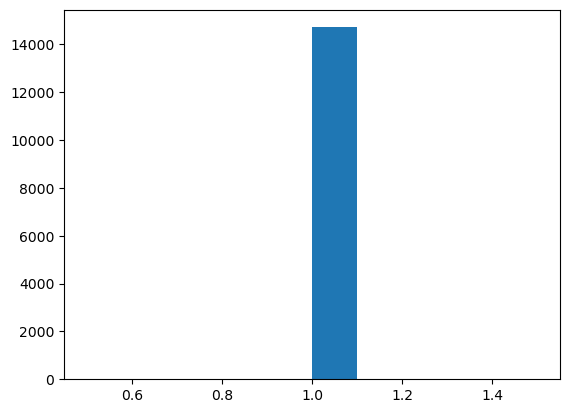

In [ ]:
import matplotlib.pyplot as plt

hvals = pd.Series(probs.cpu().detach().flatten()).value_counts().to_numpy()
plt.hist(np.maximum(np.minimum(hvals, 1), 0), bins=10)
plt.show()

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision.transforms import v2

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        """
        Args:
            image_dir (str): Path to the folder containing original images.
            mask_dir (str): Path to the folder containing mask images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
        
        assert len(self.images) == len(self.masks), "Mismatch between number of images and masks!"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])
        
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        
        to_tensor = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
        
        image = to_tensor(image)
        mask = to_tensor(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask